只能运行单个k和gamma的top免疫策略

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
mmca_top_delete_rho_vs_w.py 数据保存在rho_vs_w_top_experiment

实验：按 Phi 排序选取 top w_frac 的超边进行免疫（删除，永久），
      研究稳态感染密度 rho* 关于删除比例 w 的变化（曲线标签 "Top"）。

输出：
 - out_dir/rho_vs_w_top_perrun.csv  : 每次重复的一行记录（deletion_type='top'）
 - out_dir/rho_vs_w_top_summary.csv : 按 w 汇总，包含 mean_rho / std_rho / mean_fdel / std_fdel / mean_deleted
 - 一张 mean rho* vs w 的 png（out_dir/rho_vs_w_top_plot.png）
"""

import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # 添加并行计算库

# -------------------- 超图生成器（与你之前的一致） --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- MMCA（支持 active 掩码的实现） --------------------
class MMCAForTopDelete:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        # 三端点数组便于向量化
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        # node -> list of (edge_index, pos)
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def mmca_iter_once(self, p, Theta, active, beta_d, mu, eta, gamma):
        """
        对给定的 p, Theta, active 做一步 MMCA，返回 p_next, Theta_next, Phi (edge-wise)
        注意：在 Theta_next 计算后，会强制 Theta_next[~active] = 0.0（方法 A）
        """
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        # 计算 Q_i（跳过 inactive 边）
        Q = np.ones(self.n, dtype=float)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if not active[ei]:
                    continue
                if pos == 0:
                    oth = prod_pos0[ei]
                elif pos == 1:
                    oth = prod_pos1[ei]
                else:
                    oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * oth)
            Q[node] = prod_val
        # p_next
        p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
        # Phi (edge-wise) based on current p
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        # Theta_next (对所有边先计算，再将 inactive 的 Theta_next 置0)
        Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        Theta_next = np.clip(Theta_next, 0.0, 1.0)
        # 方法 A：强制被删除边的 Theta 永久为 0
        Theta_next[~active] = 0.0
        # 返回
        return p_next, Theta_next, Phi

    def find_steady_state(self, beta_d, mu, eta, gamma, init_frac=0.01,
                          active=None, Theta_init=None,
                          tol=1e-8, max_iters=2000, verbose=False):
        """
        迭代直到收敛（inf-norm），返回 steady p, Theta, iters, rho_history(optional)
        如果 active 为 None，则视为全部边 active。
        如果 Theta_init 给出则使用（否则初始化为 ones, 并强制 Theta_init[~active]=0）
        """
        if active is None:
            active = np.ones(self.m, dtype=bool)
        if Theta_init is None:
            Theta = np.ones(self.m, dtype=float)
            Theta[~active] = 0.0
        else:
            Theta = Theta_init.copy()
            Theta[~active] = 0.0

        p = np.full(self.n, init_frac, dtype=float)
        rho_hist = []
        iters = 0
        for it in range(max_iters):
            rho_hist.append(p.mean())
            p_next, Theta_next, Phi = self.mmca_iter_once(p, Theta, active, beta_d, mu, eta, gamma)
            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta))
            p = p_next
            Theta = Theta_next
            iters = it + 1
            if verbose and (it % 200 == 0):
                print(f"  iter={it}  rho={p.mean():.6f}  d={dp:.3e}")
            if dp < tol and dTheta < tol:
                break
        return p, Theta, Phi, iters, np.array(rho_hist)

# -------------------- 单次实验：在单图上做 top-delete --------------------
def run_one_top_delete_on_graph(hyperedges, n,
                                beta, mu, eta, gamma,
                                w_budget,       # 目标删除比例（0..1）
                                init_frac=0.01,
                                tol=1e-8, max_iters_pre=2000, max_iters_post=2000,
                                min_remaining_edges=1,
                                verbose=False):
    """
    在给定 hyperedges 上运行：
     - pre: 从 init_frac 迭代到收敛（active 全为 True）
     - 在收敛时计算 Phi，按 Phi 降序选择 top num_delete = ceil(w_budget*m) 条边并 "删除"（active=False）
         * 保证至少保留 min_remaining_edges 条边
     - post: 从 pre 收敛的 p, Theta 状态继续迭代到收敛（但 active 已修改）
    返回： rho_final, f_del_actual, num_deleted, iters_pre, iters_post
    """
    model = MMCAForTopDelete(hyperedges, n)
    m = model.m
    # 预算条数
    num_budget = int(math.ceil(float(w_budget) * m))
    if num_budget >= m:
        if m > min_remaining_edges:
            num_budget = m - min_remaining_edges
        else:
            num_budget = 0

    # 初始全 active
    active = np.ones(m, dtype=bool)
    Theta0 = np.ones(m, dtype=float)
    Theta0[~active] = 0.0

    # pre-phase: 找 steady（从统一 init_frac）
    p_pre, Theta_pre, Phi_pre, iters_pre, rho_hist_pre = model.find_steady_state(
        beta_d=beta, mu=mu, eta=eta, gamma=gamma,
        init_frac=init_frac, active=active, Theta_init=Theta0,
        tol=tol, max_iters=max_iters_pre, verbose=False
    )

    # 在 steady 时计算 Phi（使用 p_pre）
    p_i = p_pre[model.edge_i]; p_j = p_pre[model.edge_j]; p_k = p_pre[model.edge_k]
    Phi_at_ss = p_i * p_j * p_k
    Phi_at_ss[~active] = 0.0

    # 选取 top num_budget 条边按 Phi 排序（降序）
    num_delete = int(min(num_budget, int(active.sum()) - min_remaining_edges))
    delete_idx = np.array([], dtype=int)
    if num_delete > 0:
        sorted_idx = np.argsort(-Phi_at_ss)  # 降序
        # 注意只取 active 的条目
        sorted_idx = sorted_idx[np.isin(sorted_idx, np.where(active)[0])]
        delete_idx = sorted_idx[:num_delete]
        # 执行删除（永久）：active False，Theta 置 0 保证不恢复（方法 A）
        active[delete_idx] = False
        Theta_pre[delete_idx] = 0.0

    # ------------------ 从 pre 状态开始做 post-phase（推荐替换） ------------------
    # 已有变量： model, p_pre, Theta_pre, active (active 已在删除top边后被更新)
    # 我们从 p_pre, Theta_pre 开始迭代，直到收敛或达到 max_iters_post
    p = p_pre.copy()
    Theta = Theta_pre.copy()
    iters_post = 0
    for it in range(max_iters_post):
        p_next, Theta_next, Phi = model.mmca_iter_once(p, Theta, active, beta, mu, eta, gamma)
        dp = np.max(np.abs(p_next - p))
        dTheta = np.max(np.abs(Theta_next - Theta))
        p = p_next
        Theta = Theta_next
        iters_post = it + 1
        if dp < tol and dTheta < tol:
            break

    rho_final = float(p.mean())
    num_deleted = int((~active).sum())
    f_del = float(num_deleted) / float(m)

    return {
        'rho_final': rho_final,
        'num_deleted': num_deleted,
        'f_del': f_del,
        'iters_pre': iters_pre,
        'iters_post': iters_post,
        'deleted_idx': delete_idx
    }

# -------------------- 并行任务函数 --------------------
def run_single_simulation(params):
    """
    单个模拟任务的并行执行函数
    """
    (w, r, n, kappa, beta, mu, eta, gamma, init_frac, 
     tol, max_iters_pre, max_iters_post, seed_base, iw) = params
    
    # 生成随机种子
    gen_seed = None if seed_base is None else (seed_base + r + 1000 * iw)
    
    # 生成超图并运行模拟
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed)
    res = run_one_top_delete_on_graph(hyperedges, n,
                                      beta=beta, mu=mu, eta=eta, gamma=gamma,
                                      w_budget=w, init_frac=init_frac,
                                      tol=tol, max_iters_pre=max_iters_pre, max_iters_post=max_iters_post,
                                      min_remaining_edges=1, verbose=False)
    
    # 返回结果
    return {
        'deletion_type': 'top',
        'theta_del': -1.0,
        'w_budget': float(w),
        'run': int(r),
        'rho_final': float(res['rho_final']),
        'f_del': float(res['f_del']),
        'num_deleted': int(res['num_deleted']),
        'iters_pre': int(res['iters_pre']),
        'iters_post': int(res['iters_post'])
    }

# -------------------- 并行扫描 w, 重复实验并保存结果 --------------------
def sweep_w_top_delete_parallel(n, kappa, beta, mu, eta, gamma,
                                w_list, R=20, init_frac=0.01,
                                tol=1e-8, max_iters_pre=2000, max_iters_post=2000,
                                seed_base=12345, out_dir="out_top_delete", n_jobs=-1):
    """
    并行版本的扫描函数
    """
    os.makedirs(out_dir, exist_ok=True)
    
    print(f"[INFO] 开始并行计算，共 {len(w_list)} 个 w 值，每个 {R} 次重复，总任务数: {len(w_list) * R}")
    print(f"[INFO] 使用 {n_jobs} 个并行工作进程")
    
    t0 = time.time()
    
    # 准备所有参数组合
    param_combinations = []
    for iw, w in enumerate(w_list):
        for r in range(R):
            params = (w, r, n, kappa, beta, mu, eta, gamma, init_frac, 
                     tol, max_iters_pre, max_iters_post, seed_base, iw)
            param_combinations.append(params)
    
    # 使用 joblib 并行执行
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(run_single_simulation)(params) 
        for params in param_combinations
    )
    
    # 收集结果
    df = pd.DataFrame(results)
    
    # 保存详细结果
    perrun_fn = os.path.join(out_dir, "rho_vs_w_top_perrun.csv")
    df.to_csv(perrun_fn, index=False, float_format="%.6f")
    print(f"[SAVED] per-run CSV -> {perrun_fn}")

    # 汇总：按 w_budget 分组
    summary = df.groupby(['w_budget']).agg(
        mean_rho=('rho_final', 'mean'),
        std_rho=('rho_final', 'std'),
        mean_fdel=('f_del', 'mean'),
        std_fdel=('f_del', 'std'),
        mean_deleted=('num_deleted', 'mean')
    ).reset_index().sort_values('w_budget')

    summary_fn = os.path.join(out_dir, "rho_vs_w_top_summary.csv")
    summary.to_csv(summary_fn, index=False, float_format="%.6f")
    print(f"[SAVED] summary CSV -> {summary_fn}")
    
    elapsed = time.time() - t0
    print(f"Total time: {elapsed:.1f}s")
    return df, summary

# -------------------- 参数（修改在此处） --------------------

# 网络 / 模型参数
n = 1500
kappa = 9.0

# 固定传播参数
beta = 0.35
mu = 0.1
eta = 0.6
gamma = 0.03

# 实验参数
w_list = np.concatenate([  # 只删除最多到 50% 的边（你可以扩展到 1.0）
    np.arange(0.0, 0.65, 0.05),
    np.arange(0.75, 0.8, 0.01),
    np.arange(0.8, 1.0, 0.01),
])   
R = 5                               # 每个 w 重复次数
init_frac = 0.3

# 迭代收敛参数
tol = 1e-8
max_iters_pre = 1000
max_iters_post = 1000

# 并行参数
n_jobs = 18  # 使用所有可用的CPU核心，可以设置为具体数字如 4、8 等

# 其他
seed_base = 12345
out_dir = "rho_vs_w_experiment_kappa_9"
os.makedirs(out_dir, exist_ok=True)

# 运行并行扫描并保存
df_runs, summary = sweep_w_top_delete_parallel(
    n=n, kappa=kappa,
    beta=beta, mu=mu, eta=eta, gamma=gamma,
    w_list=w_list, R=R, init_frac=init_frac,
    tol=tol, max_iters_pre=max_iters_pre, max_iters_post=max_iters_post,
    seed_base=seed_base, out_dir=out_dir, n_jobs=n_jobs
)

print("Done.")

[INFO] 开始并行计算，共 39 个 w 值，每个 5 次重复，总任务数: 195
[INFO] 使用 18 个并行工作进程


[Parallel(n_jobs=18)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    2.7s


[SAVED] per-run CSV -> rho_vs_w_experiment_kappa_9\rho_vs_w_top_perrun.csv
[SAVED] summary CSV -> rho_vs_w_experiment_kappa_9\rho_vs_w_top_summary.csv
Total time: 34.0s
Done.


[Parallel(n_jobs=18)]: Done 195 out of 195 | elapsed:   33.9s finished


加载了 38 个数据点
图片已保存 -> rho_vs_w_experiment_kappa_9\rho_vs_w_top_simple_plot.png


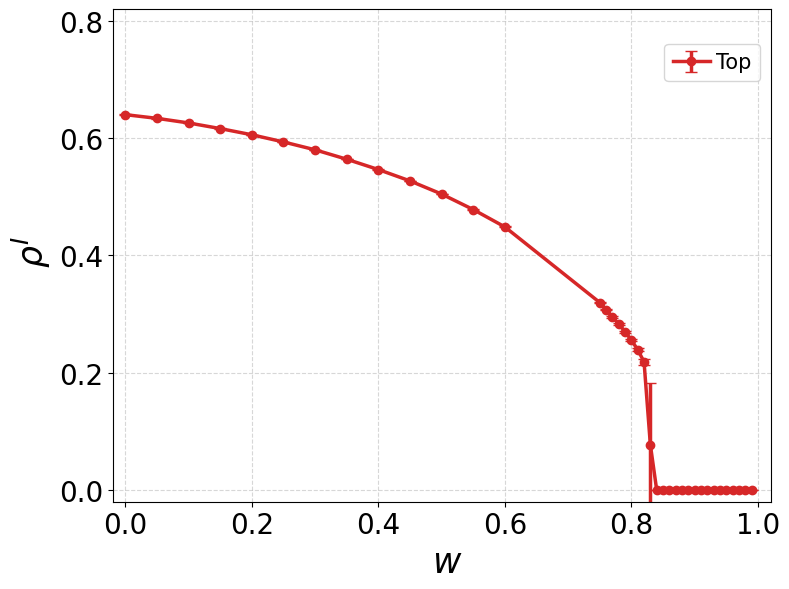

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
mmca_top_delete_simple_plot.py

简单绘图：读取Top-Phi删除策略结果并绘制主图。
"""

import os
import pandas as pd
import matplotlib.pyplot as plt

out_dir="rho_vs_w_experiment_kappa_9"
"""
绘制简单的主图：感染密度 vs 删除比例
"""
# 读取汇总数据
summary_file = os.path.join(out_dir, "rho_vs_w_top_summary.csv")

if not os.path.exists(summary_file):
    print(f"错误：找不到结果文件 {summary_file}")
    print("请先运行模拟代码生成结果文件")

# 加载数据
summary_df = pd.read_csv(summary_file)
print(f"加载了 {len(summary_df)} 个数据点")

# 绘制图形
plt.figure(figsize=(8, 6))

plt.errorbar(summary_df['w_budget'], summary_df['mean_rho'], 
                yerr=summary_df['std_rho'], 
                fmt='-o', linewidth=2.5, markersize=6,
                capsize=4, label='Top', color='#d62728')
plt.xlabel(r" $w$ ", fontsize=25)
plt.ylabel(r" $ρ^I$ ", fontsize=25)
# plt.title("Steady-state prevalence ρ* vs edge removal fraction w", fontsize=14)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 0.82)
plt.xticks(np.linspace(0,1,6), fontsize=20)
plt.yticks(np.linspace(0,0.8,5), fontsize=20)
plt.grid(alpha=0.5, linestyle='--', linewidth=0.8)

legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 0.95),
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    # ncol=2,              # 分两列
    handlelength=1.8,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)
plt.tight_layout()

# 保存图片
plot_file = os.path.join(out_dir, "rho_vs_w_top_simple_plot.png")
plt.tight_layout()
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"图片已保存 -> {plot_file}")
plt.show()
